# Analysis of specific junction
## Analyse block trees
In this notebook trees that are created based on blocks (that at least appear 3 times and have a length > 1000) are analysed.

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, filter_paths_by_block_freq, compute_majority_path, consensus_paths_and_assignments, find_consensus_paths_core, filter_deduplicated_paths, renumber_context_numbering
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, load_all_insertions_summaries, load_all_inversions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, load_all_translocations_summaries

### Make consensus clustering based on core blocks and find consensus paths per cluster and validate clustering choices
0. build trees, cluster and build consensus paths
1. validate threshold to cut core block tree
2. Compare core block trees to see whether day match with treeknit

Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/XXVMWZCEKI_r__YUOECYBHUS_r
Isolate NZ_CP133923.1 filtered out: 46/80 anchor blocks (57.50%)
Isolate NZ_CP134384.1 filtered out: 46/80 anchor blocks (57.50%)
Isolate NZ_CP107143.1 filtered out: 105/194 anchor blocks (54.12%)
Isolate NZ_CP070593.1 filtered out: 70/127 anchor blocks (55.12%)
Isolate NZ_CP019008.1 filtered out: 46/80 anchor blocks (57.50%)
Isolate NZ_CP107174.1 filtered out: 105/194 anchor blocks (54.12%)
Isolate NZ_CP124467.1 filtered out: 21/46 anchor blocks (45.65%)
Isolate NZ_OX637964.1 filtered out: 15/47 anchor blocks (31.91%)
Isolate NZ_CP032265.1 filtered out: 48/116 anchor blocks (41.38%)
Isolate NZ_CP133927.1 filtered out: 62/132 anchor blocks (46.97%)
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1},

,file,block_id,context,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len
0,block_2172460183964009623_ctx_nocontext_sequen...,2172460183964009623,,3,1130,1130,0,0,0,0.000000,0.000000,0.000000,11,11,False,False,1129
1,block_2650703147047041061_ctx_nocontext_sequen...,2650703147047041061,,3,233,233,0,0,0,0.000000,0.000000,0.000000,133,133,False,False,233
2,block_2920284315440978119_ctx_nocontext_sequen...,2920284315440978119,,3,1362,1362,0,0,0,0.000000,0.000000,0.000000,10,10,False,False,1362
3,block_4984479779645433445_ctx_nocontext_sequen...,4984479779645433445,,34,153,143,8,2,0,0.000000,0.000000,0.000000,37,37,False,False,143
4,block_5853345250725139292_ctx_5676880524403055...,5853345250725139292,5676880524403055004_1,3,124,124,0,0,0,0.000000,0.000000,0.000000,327,193,True,False,124
5,block_6638601397933865622_ctx_5676880524403055...,6638601397933865622,5676880524403055004_1,3,1092,1092,0,0,0,0.000000,0.000000,0.000000,356,201,True,False,1096
6,block_8529656649389775164_ctx_nocontext_sequen...,8529656649389775164,,3,2210,2210,0,0,0,0.000000,0.000000,0.000000,10,10,False,False,2210
7,block_8854941578893199967_ctx_nocontext_sequen...,8854941578893199967,,5,261,216,36,9,14,0.064815,0.028302,0.018868,61,61,False,False,309
8,block_9130806199882225000_ctx_nocontext_sequen...,9130806199882225000,,3,103,103,0,0,0,0.000000,0.000000,0.000000,49,49,False,False,103
9,block_10630905992013787204_ctx_567688052440305...,10630905992013787204,5676880524403055004_1,3,771,771,0,0,0,0.000000,0.000000,0.000000,356,201,True,False,771


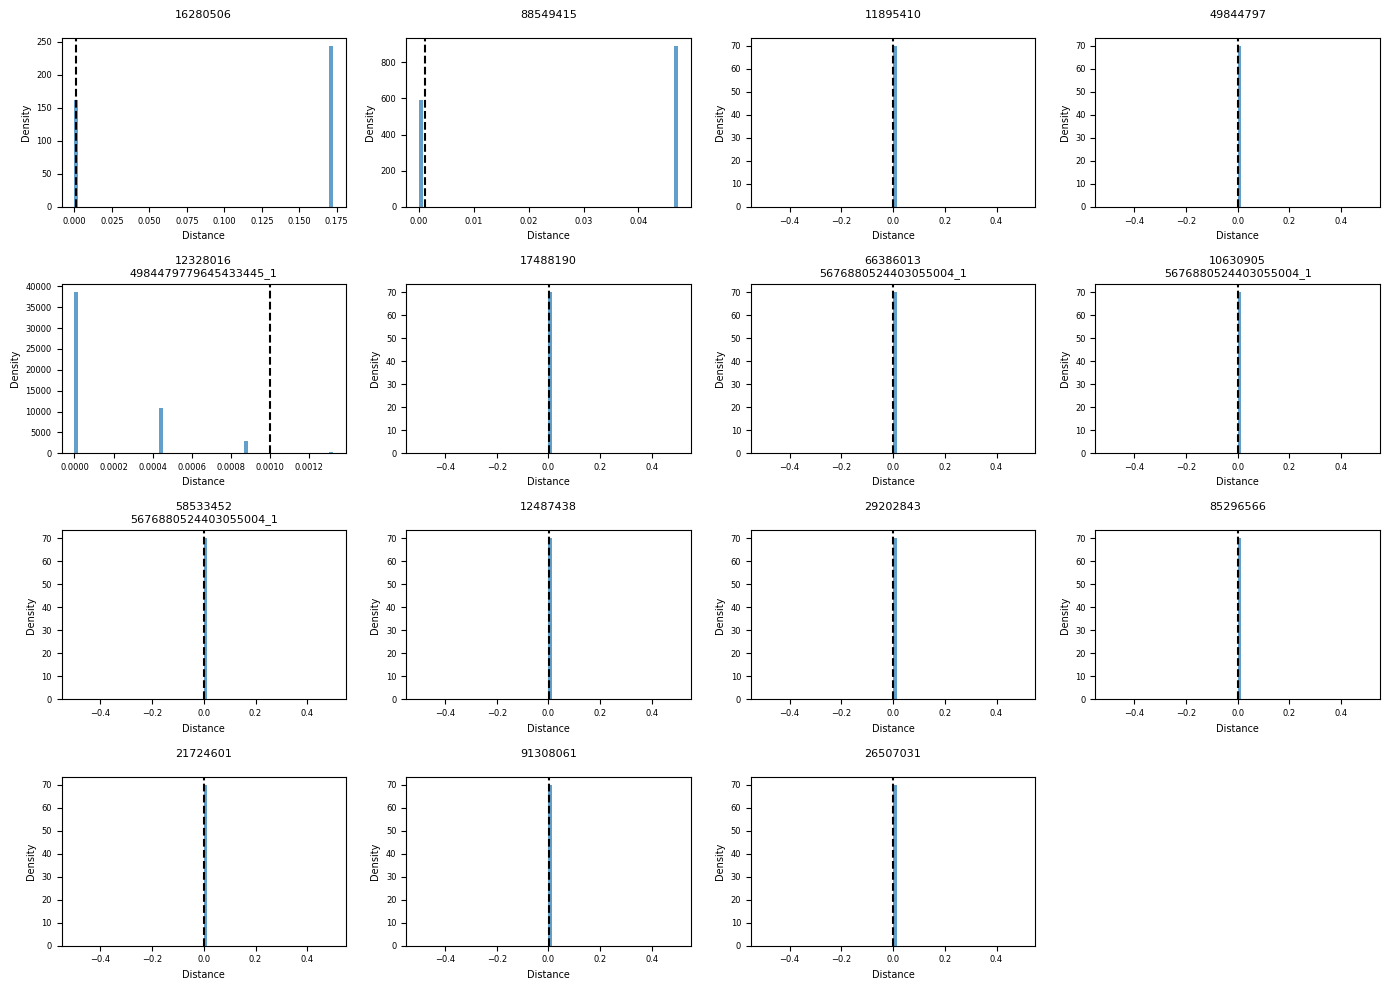

3 / 8 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}]
Block 9474894503673110699 ctx= only appeared once in cluster. Assuming gain with ancestral state 0.
Block 3973231311631193246 ctx= only appeared once in cl

,file,block_id,context,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len
0,block_1096734789754066601_ctx_nocontext_sequen...,1096734789754066601,,2,876,876,0,0,7,0.007991,0.007991,0.003995,69,69,False,False,876
1,block_1102880553193381275_ctx_nocontext_sequen...,1102880553193381275,,31,912,912,0,0,0,0.000000,0.000000,0.000000,189,189,False,False,912
2,block_1579633055325618036_ctx_nocontext_sequen...,1579633055325618036,,4,454,446,8,0,3,0.006726,0.003362,0.001679,8,8,False,False,446
3,block_1874764326487286045_ctx_nocontext_sequen...,1874764326487286045,,31,135,135,0,0,0,0.000000,0.000000,0.000000,188,188,False,False,138
4,block_1942024545331838172_ctx_nocontext_sequen...,1942024545331838172,,2,110,110,0,0,0,0.000000,0.000000,0.000000,69,69,False,False,110
5,block_2643599805046114706_ctx_nocontext_sequen...,2643599805046114706,,31,143,134,0,9,0,0.000000,0.000000,0.000000,188,188,False,False,142
6,block_3893266171437256324_ctx_nocontext_sequen...,3893266171437256324,,31,351,343,8,0,0,0.000000,0.000000,0.000000,188,188,False,False,343
7,block_4666613665082505501_ctx_nocontext_sequen...,4666613665082505501,,13,167,127,40,0,0,0.000000,0.000000,0.000000,204,202,True,False,167
8,block_4711013568290284877_ctx_nocontext_sequen...,4711013568290284877,,31,201,201,0,0,0,0.000000,0.000000,0.000000,189,189,False,False,201
9,block_4984479779645433445_ctx_nocontext_sequen...,4984479779645433445,,31,151,143,8,0,0,0.000000,0.000000,0.000000,37,37,False,False,143


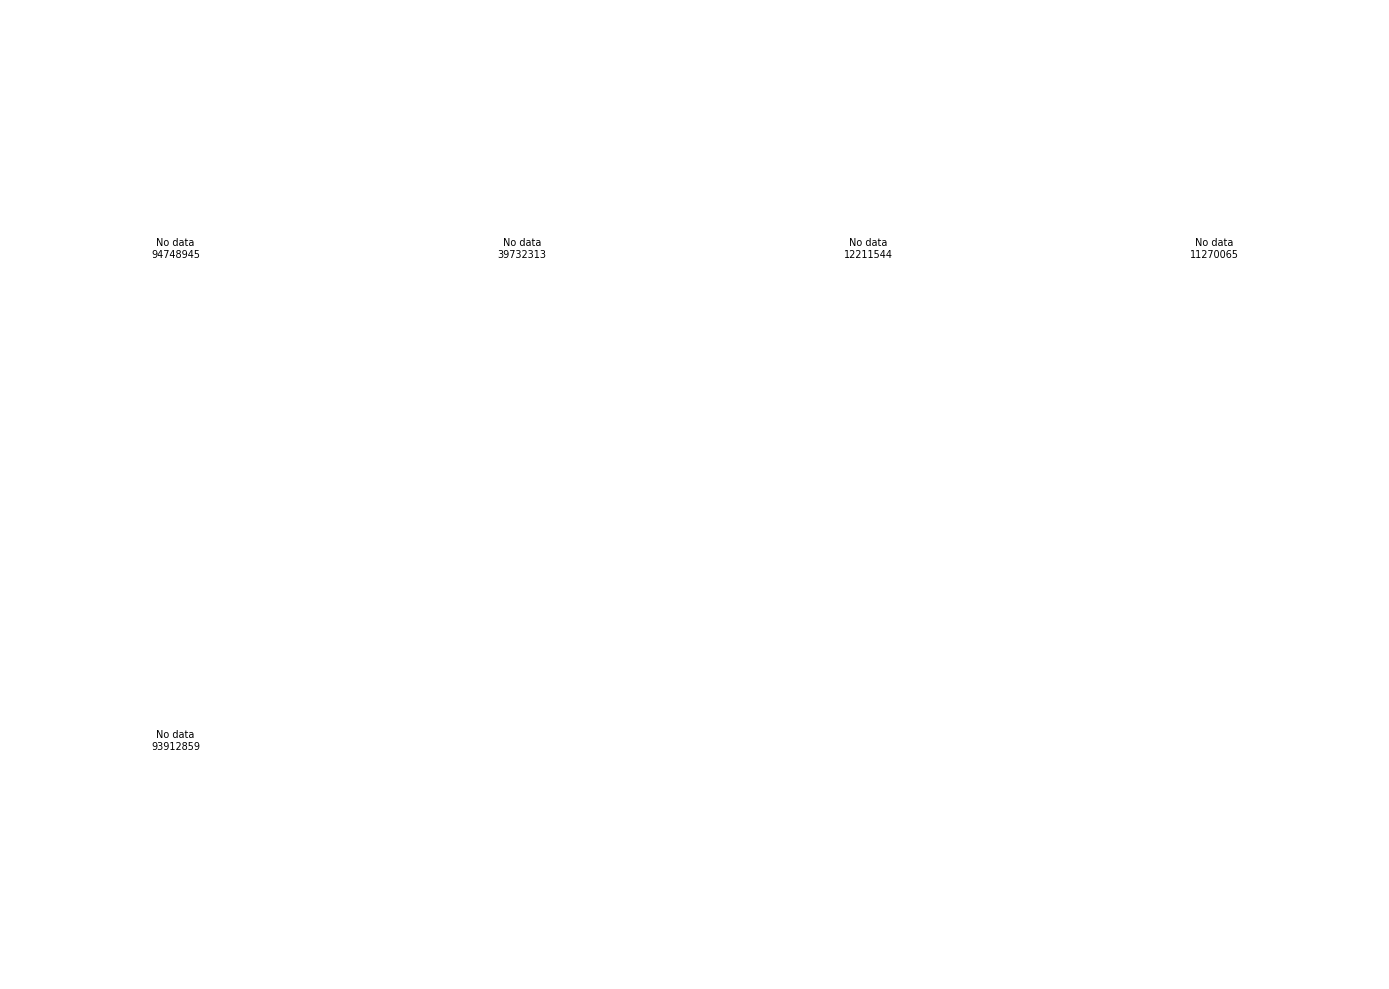

2 / 2 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0, 1}, {0, 1}, {0, 

,file,block_id,context,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len
0,block_1102880553193381275_ctx_nocontext_sequen...,1102880553193381275,,8,912,912,0,0,0,0.000000,0.000000,0.000000,189,189,False,False,912
1,block_1220512262754833437_ctx_nocontext_sequen...,1220512262754833437,,8,387,387,0,0,4,0.010336,0.002584,0.001292,205,205,False,False,395
2,block_1874764326487286045_ctx_nocontext_sequen...,1874764326487286045,,8,167,167,0,0,0,0.000000,0.000000,0.000000,188,188,False,False,138
3,block_2643599805046114706_ctx_nocontext_sequen...,2643599805046114706,,8,142,142,0,0,0,0.000000,0.000000,0.000000,188,188,False,False,142
4,block_3003393643283907345_ctx_nocontext_sequen...,3003393643283907345,,8,237,237,0,0,0,0.000000,0.000000,0.000000,199,197,True,False,322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,block_17687220482716050848_ctx_nocontext_seque...,17687220482716050848,,8,465,465,0,0,0,0.000000,0.000000,0.000000,206,206,False,False,457
85,block_17841106078370737378_ctx_nocontext_seque...,17841106078370737378,,8,587,587,0,0,0,0.000000,0.000000,0.000000,200,198,True,False,587
86,block_18075769245771779038_ctx_nocontext_seque...,18075769245771779038,,8,134,134,0,0,0,0.000000,0.000000,0.000000,65,65,False,False,134
87,block_18098086728912724578_ctx_nocontext_seque...,18098086728912724578,,8,2589,2589,0,0,3,0.001159,0.000000,0.000000,197,197,False,False,2589


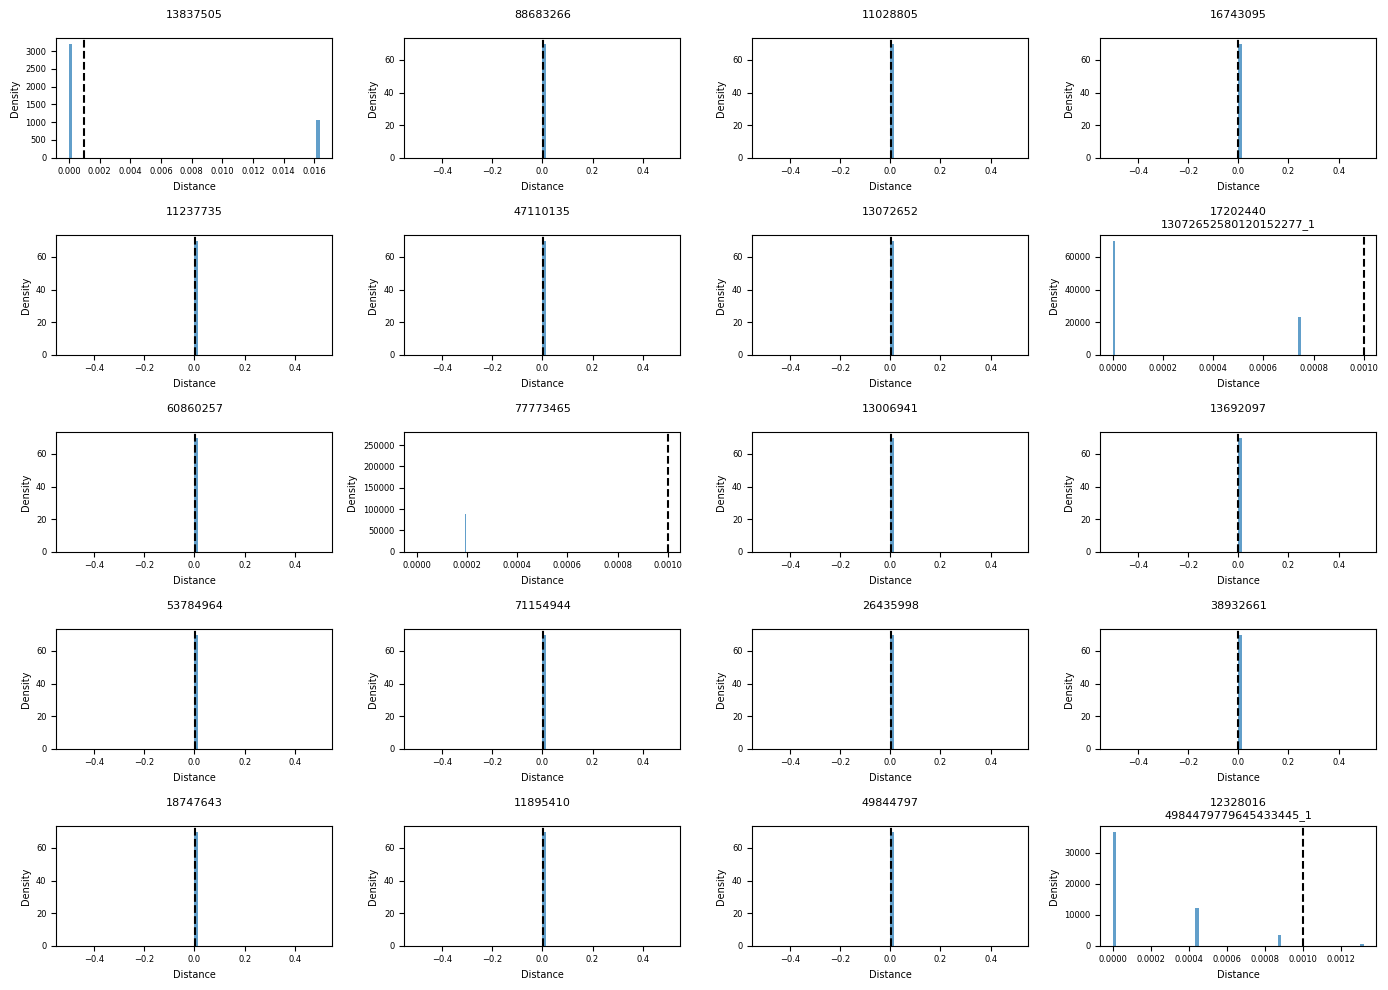

27 / 41 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
Cluster 10: only 3/8 isolates pass strict anchor filter (38% < 80%), retrying with relaxed threshold (30%).
[{1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {0, 1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, 

,file,block_id,context,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len
0,block_219677687013575207_ctx_nocontext_sequenc...,219677687013575207,,4,687,687,0,0,0,0.000000,0.000000,0.000000,5,5,False,False,687
1,block_722694439242672951_ctx_nocontext_sequenc...,722694439242672951,,5,631,631,0,0,32,0.050713,0.018471,0.009236,8,8,False,False,631
2,block_820162239835546973_ctx_nocontext_sequenc...,820162239835546973,,4,115,115,0,0,0,0.000000,0.000000,0.000000,4,4,False,False,115
3,block_1831565274893222164_ctx_nocontext_sequen...,1831565274893222164,,5,1473,1473,0,0,60,0.040733,0.009129,0.004564,5,5,False,False,1473
4,block_4000317901111990736_ctx_nocontext_sequen...,4000317901111990736,,4,1206,1206,0,0,113,0.093698,0.043442,0.021721,4,4,False,False,1197
5,block_4666613665082505501_ctx_nocontext_sequen...,4666613665082505501,,4,127,127,0,0,0,0.000000,0.000000,0.000000,204,202,True,False,167
6,block_5360336986885480552_ctx_nocontext_sequen...,5360336986885480552,,4,948,948,0,0,44,0.046414,0.023207,0.011603,5,5,False,False,948
7,block_5475050014392564322_ctx_nocontext_sequen...,5475050014392564322,,5,3392,3392,0,0,102,0.030071,0.012028,0.006014,5,5,False,False,3392
8,block_5817625914614044188_ctx_1601536002413788...,5817625914614044188,16015360024137885230_1,3,1012,1012,0,0,0,0.000000,0.000000,0.000000,210,207,True,False,1068
9,block_5905508257373308746_ctx_nocontext_sequen...,5905508257373308746,,3,3566,3566,0,0,0,0.000000,0.000000,0.000000,3,3,False,False,3566


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:1351: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.



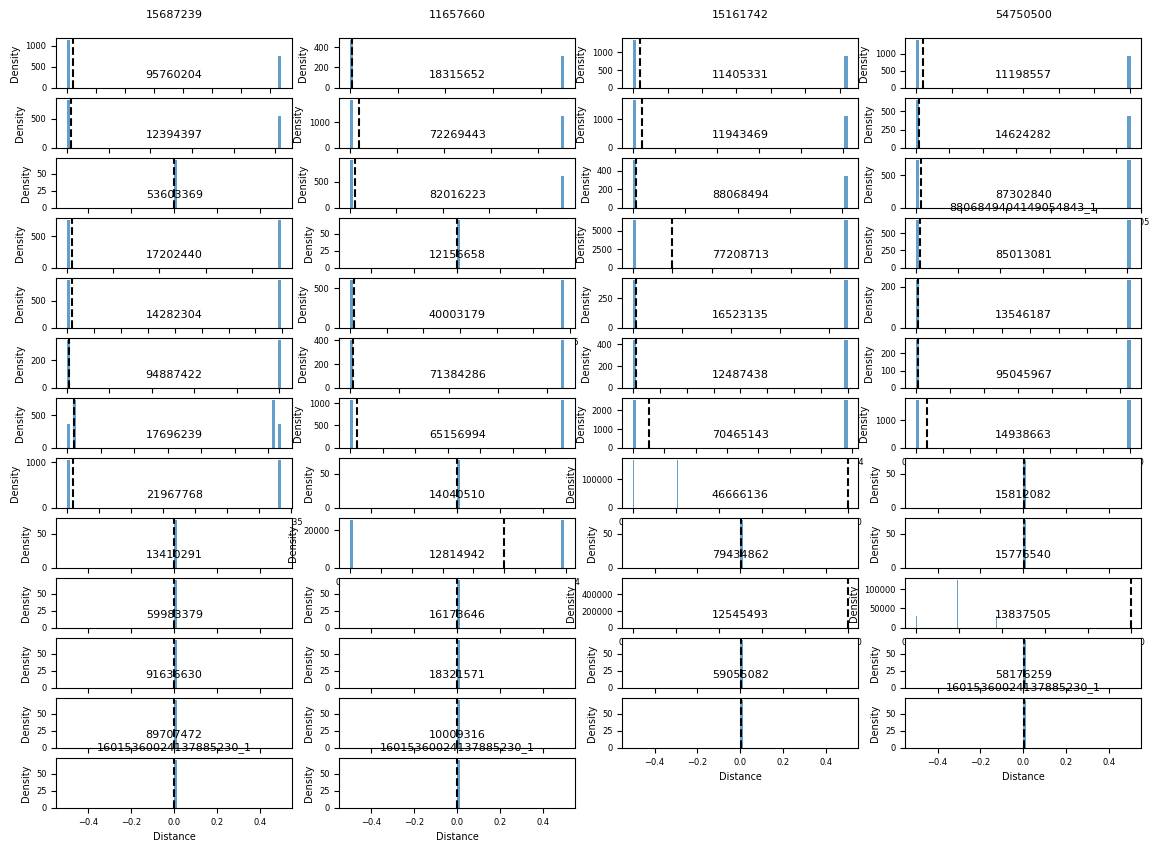

3 / 8 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
Cluster 13: only 0/1 isolates pass strict anchor filter (0% < 80%), retrying with relaxed threshold (30%).
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}

,file,block_id,context,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len
0,block_1579633055325618036_ctx_nocontext_sequen...,1579633055325618036,,2,446,446,0,0,1,0.002242,0.002242,0.001121,8,8,False,False,446
1,block_14647159893189274541_ctx_nocontext_seque...,14647159893189274541,,2,2253,2253,0,0,0,0.000000,0.000000,0.000000,9,9,False,False,2261


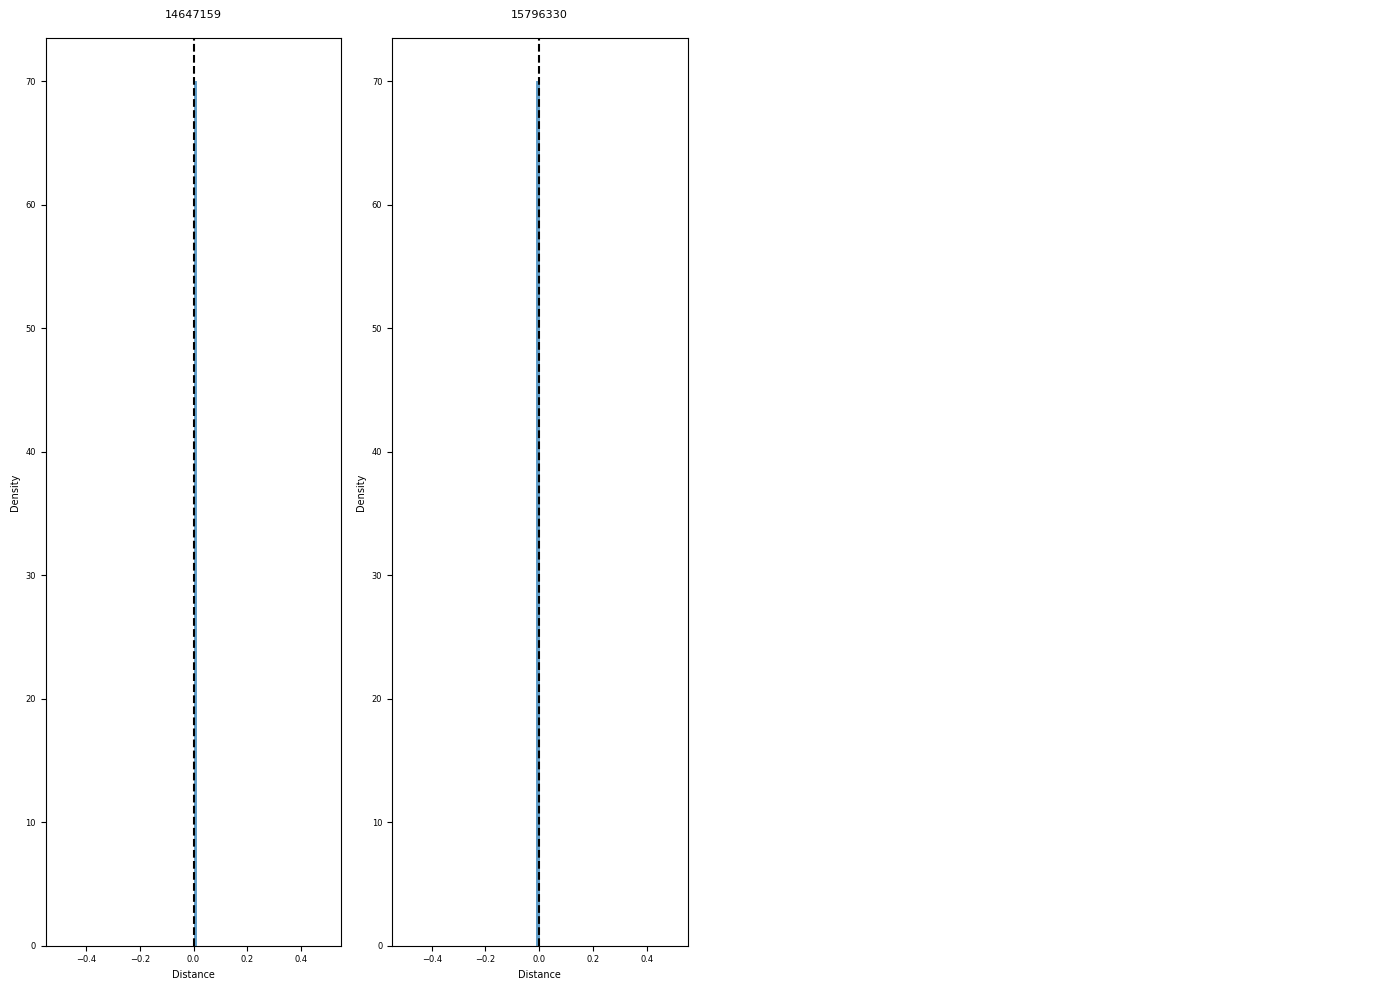

6 / 8 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, 

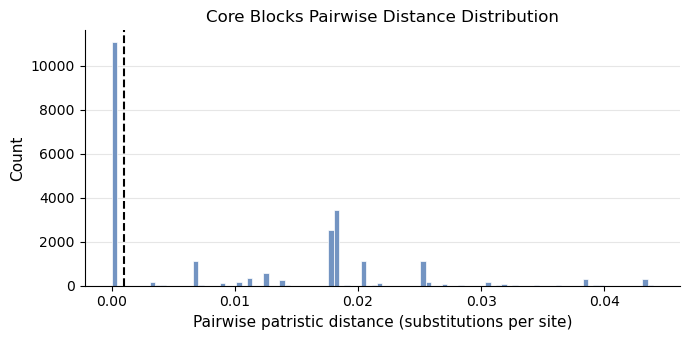

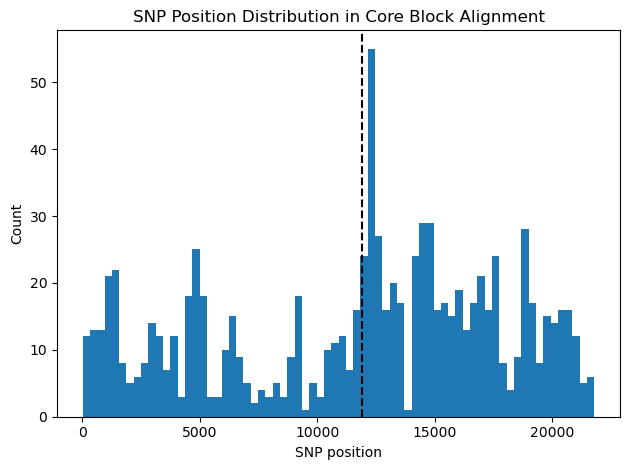

In [6]:

#example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
#example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f"
example_junction = "XXVMWZCEKI_r__YUOECYBHUS_r"
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue, ambiguities_df = find_consensus_paths_core(example_junction, plot_consensus=True, plot_pair_dist=True, plot_snp_dist= True, plot_ambiguities=True, clustering_bl_thresh=0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')

In [10]:
# preprocess trees of the two flanking core blocks

strip_newick_suffixes("../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_16671105780806995519_aln.tree", "../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_16671105780806995519_aln_isonames.tree")
strip_newick_suffixes("../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_18146406109094649449_aln.tree", "../results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f/block_18146406109094649449_aln_isonames.tree")

Results from manual observation:
- depending on which core block we look at, NZ_AP018784.1 is assigned to different clusters
- clustering based on core block trees seems to reflect by eye estimated consensus clustering pretty well

Compare core block trees:
```
cd /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/block_alignments/RYYAQMEJGY_r__ZTHKZYHPIX_f
treeknit block_16671105780806995519_aln_isonames.tree block_18146406109094649449_aln_isonames.tree --auspice-view
```

Afterwards put json files in https://auspice.us/

### Retrieve insertions and deletions

In [8]:
path_dict['NZ_CP018991.1'] # analyze further, might be bug

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|7385292223686217602_1]_[5670023643096029701|+|7385292223686217602_1]_[11734174143264340999|+|7385292223686217602_1]_[14230977707636736595|+|7385292223686217602_1]_[15169038317952353904|+|7385292223686217602_1]_[6912564871896832629|+|7385292223686217602_1]_[1833494430068775247|+|7385292223686217602_1]_[441542311555414356|+|7385292223686217602_1]_[578008595963632427|+|7385292223686217602_1]_[13050355685719842709|+|7385292223686217602_1]_[16400092613407614919|+|7385292223686217602_1]_[5598563553016563611|+|7385292223686217602_1]_[6523613490405440663|+|7385292223686217602_1]_[17885250

In [8]:
consensus_paths_plotting[0]

[16671105780806995519|+|]_[10958655627444534111|+|]_[3419103275029521940|+|]_[1448964389002043948|+|]_[7166485448600219032|+|]_[10480880799551222441|+|]_[9943278599560102111|+|]_[7385292223686217602|+|]_[13612719202651021848|-|7385292223686217602_1]_[3226134370544314880|-|7385292223686217602_1]_[17141892380880723886|-|7385292223686217602_1]_[16424442392483324144|-|7385292223686217602_1]_[6800119766726695319|+|]_[5670023643096029701|+|]_[11734174143264340999|+|]_[14230977707636736595|+|]_[15169038317952353904|+|]_[6912564871896832629|+|]_[1833494430068775247|+|]_[441542311555414356|+|]_[578008595963632427|+|]_[13050355685719842709|+|]_[16400092613407614919|+|]_[5598563553016563611|+|]_[6523613490405440663|+|]_[5285753434584984164|-|6523613490405440663_1]_[11300668210740262185|-|6523613490405440663_1]_[5339633743814445085|-|6523613490405440663_1]_[13388509215143776072|-|6523613490405440663_1]_[7110182631703495678|+|]_[951767945673275678|+|]_[8987038859492738001|+|951767945673275678_1]_[1

In [3]:
#example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f" # junction has 216 isolates
#example_junction = "CIRMBUYJFK_f__CWCCKOQCWZ_r"

example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

for i in range(1, len(consensus_paths_plotting) + 1):
    insertions, deletions, inversions, translocations = get_insertions_deletions_from_consensus(assignment_df_plotting, consensus_paths_plotting, path_dict, consensus = i)
    summarize_inversions_consensus(inversions, example_junction, example_pangraph, consensus_id = i, parent_dir = "../results/atb_lookup/inversions", save_df=True)
    summarize_translocations_consensus(translocations, example_junction, example_pangraph, consensus_id = i, parent_dir = "../results/atb_lookup/translocations", save_df=True)
    write_insertions_fasta(example_junction, example_pangraph, insertions, consensus = i, save_df=True)
    deletions_df = summarize_deletions_consensus(deletions, example_junction, example_pangraph, path_dict, assignment_df_plotting, consensus_id=i, parent_dir = "../results/atb_lookup/deletions", rerun_alignment=False, save_df=True)

# 40 min, TODO: delete all fasta files and rerun to get proper sequences, only when code version is final




Insertions:
NZ_CP102061.1 INSERTED: [3613498299447014379|-|]_[139818706072034984|-|]
NZ_CP102061.1 INSERTED: [2150995670991051021|+|]
NZ_CP080116.1 INSERTED: [9498745749412710955|+|]
NZ_CP080116.1 INSERTED: [3613498299447014379|-|]_[139818706072034984|-|]
NZ_CP080116.1 INSERTED: [2150995670991051021|+|]
NZ_CP124517.1 INSERTED: [4892779445509988905|-|7385292223686217602_1]_[8843624255696360543|-|7385292223686217602_1]_[5285753434584984164|-|7385292223686217602_2]_[11300668210740262185|-|7385292223686217602_2]_[5339633743814445085|-|7385292223686217602_2]_[13388509215143776072|-|7385292223686217602_2]
NZ_CP019015.1 INSERTED: [3613498299447014379|-|]_[139818706072034984|-|]
NZ_CP019015.1 INSERTED: [2150995670991051021|+|]
NZ_CP018991.1 INSERTED: [17885250183886920782|+|7385292223686217602_1]
NZ_CP018991.1 INSERTED: [2150995670991051021|+|]
NZ_CP018991.1 INSERTED: [4892779445509988905|-|7385292223686217602_1]_[8843624255696360543|-|7385292223686217602_1]
NZ_CP018991.1 INSERTED: [1130066821

In [4]:
load_all_translocations_summaries("../results/atb_lookup/translocations", example_junction, save_df=True)

,junction_name,consensus,genome_name,path,translocation,length,start_pos,end_pos,ctx
0,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP018991.1,[5285753434584984164|-|7385292223686217602_1],translocation0,103,62672,62775,12922793938882367282
1,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP035476.1,[13388509215143776072|+|7385292223686217602_2]...,translocation0,797,48110,48907,5475115445007176344_2
2,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP010876.1,[13388509215143776072|+|7385292223686217602_2]...,translocation0,797,48110,48907,5475115445007176344_2
3,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP124460.1,[5285753434584984164|-|7385292223686217602_1]_...,translocation0,797,27616,28413,5475115445007176344
4,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_JAPVBX010000001.1,[6800119766726695319|+|7385292223686217602_1]_...,translocation0,5645,12501,18146,7385292223686217602
5,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_JAPVBX010000001.1,[441542311555414356|+|7385292223686217602_1]_[...,translocation1,34652,18257,52909,7385292223686217602
6,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_JAPVBX010000001.1,[15911069344949453994|+|7385292223686217602_1]...,translocation2,1766,53036,54802,7385292223686217602
7,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP018953.1,[5285753434584984164|-|7385292223686217602_1],translocation0,103,73294,73397,5475115445007176344
8,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP095520.1,[13388509215143776072|+|7385292223686217602_2]...,translocation0,797,48099,48896,5475115445007176344_2
9,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP035720.1,[13388509215143776072|+|7385292223686217602_2]...,translocation0,797,48110,48907,5475115445007176344_2


In [5]:
load_all_insertions_summaries("../results/atb_lookup/insertions", example_junction, save_df=True)

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx
0,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP102061.1,[3613498299447014379|-|]_[139818706072034984|-|],segment_0,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,2580,-,37636,40215,2793330396965050145
1,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP102061.1,[2150995670991051021|+|],segment_1,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,127,+,44940,45061,10401150471569339000
2,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP080116.1,[9498745749412710955|+|],segment_0,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,12550,+,1275,13825,16671105780806995519
3,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP080116.1,[3613498299447014379|-|]_[139818706072034984|-|],segment_1,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,2580,-,67512,70092,12885162208417639662
4,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP080116.1,[2150995670991051021|+|],segment_2,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,127,+,70599,70720,10401150471569339000
...,...,...,...,...,...,...,...,...,...,...,...
337,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP124334.1,[16424442392483324144|+|8046715219054472333_1]...,segment_0,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,2530,+,53903,56443,648713480049732840
338,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP128916.1,[8987038859492738001|-|13441773807216920667_1],segment_0,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,764,-,100103,100880,13441773807216920667
339,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP124511.1,[8987038859492738001|+|7385292223686217602_1],segment_0,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,764,+,30134,30911,5670023643096029701
340,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP103465.1,[8987038859492738001|-|9064600273910720801_1],segment_0,../results/atb_lookup/insertions/RYYAQMEJGY_r_...,764,-,9234,10011,9064600273910720801


In [6]:
load_all_inversions_summaries("../results/atb_lookup/inversions", example_junction, save_df=True)

,junction_name,consensus,genome_name,path,inversion,length,start_pos,end_pos,strand,ctx
0,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP035476.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,21429,26681,48110,-,5475115445007176344
1,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP124415.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,1232,72850,74082,-,5475115445007176344
2,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP096110.1,[12487832503496394897|-|]_[8748029925198249866...,inversion0,64099,15034,83077,-,7385292223686217602
3,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP054219.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,21430,72824,94254,-,5475115445007176344
4,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP010876.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,21429,26681,48110,-,5475115445007176344
5,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP014316.1,[14530442464259238252|-|],inversion0,288,98786,99074,-,2632449877243298885
6,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP035477.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,21430,72827,94257,-,5475115445007176344
7,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP124424.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,21440,70300,92986,-,5475115445007176344
8,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP027534.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,1241,67723,68964,-,5475115445007176344
9,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP103562.1,[4892779445509988905|-|7385292223686217602_1]_...,inversion0,456,22728,23184,-,13050355685719842709


In [7]:
load_all_deletions_summaries("../results/atb_lookup/deletions", example_junction, save_df=True).sort_values(['consensus','path'])

,junction_name,consensus,genome_name,path,deletion,consensus_sequence,length,position,strand,ctx
5,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP103592.1,[10933325453849816616|+|7385292223686217602_1],deletion0,acggcggcaaccgtcaccggcagcaaccgtctgggcaatttcactg...,171,50291,+,3572206297778278323
21,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_JAPVBX010000001.1,[10958655627444534111|+|],deletion0,gtatgtaaatagacctcaactgaggtctttttttatgcctgaaatc...,104,1317,+,16671105780806995519
28,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP018970.1,[10958655627444534111|+|],deletion0,gtatgtaaatagacctcaactgaggtctttttttatgcctgaaatc...,104,1317,+,16671105780806995519
32,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_AP026794.1,[10958655627444534111|+|],deletion0,gtatgtaaatagacctcaactgaggtctttttttatgcctgaaatc...,104,1318,+,16671105780806995519
41,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_1,NZ_CP107172.1,[10958655627444534111|+|],deletion0,gtatgtaaatagacctcaactgaggtctttttttatgcctgaaatc...,104,1317,+,16671105780806995519
...,...,...,...,...,...,...,...,...,...,...
65,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP124502.1,[5711425219771176465|+|1275445164131886809_2],deletion0,gacacgttcttactatgtgtcgatgaaattcgcttttttaaacatg...,139,17031,+,1275445164131886809_2
66,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP124345.1,[5711425219771176465|+|1275445164131886809_2],deletion0,gacacgttcttactatgtgtcgatgaaattcgcttttttaaacatg...,139,17042,+,1275445164131886809_2
67,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP124475.1,[5711425219771176465|+|1275445164131886809_2],deletion0,gacacgttcttactatgtgtcgatgaaattcgcttttttaaacatg...,139,17032,+,1275445164131886809_2
68,RYYAQMEJGY_r__ZTHKZYHPIX_f,consensus_5,NZ_CP124495.1,[5711425219771176465|+|1275445164131886809_2],deletion0,gacacgttcttactatgtgtcgatgaaattcgcttttttaaacatg...,139,17032,+,1275445164131886809_2


### See whether block tree clustering is consistent with consensus block tree clustering
1. decide on sensible thresholds for core block tree clustering
2. Cluster by trees based on single blocks and see if clustering follows consensus paths

/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_70434/558142800.py:5: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,file,block_id,n_seqs,alignment_len,core_len,left_overhang,right_overhang,mismatch_columns,mismatch_fraction,avg_pairwise_dist,avg_consensus_dist,count,n_strains,duplicated,core,len,tree_built
65,block_6362012061147730151_aln.fa,6362012061147730151,196,1085,1075,10,0,0,0.000000,0.000000,0.000000,196,196,False,False,1083,True
133,block_12427157752372396874_aln.fa,12427157752372396874,3,1509,1509,0,0,0,0.000000,0.000000,0.000000,3,3,False,False,1509,True
173,block_17897566196295069196_aln.fa,17897566196295069196,182,1320,1320,0,0,0,0.000000,0.000000,0.000000,182,182,False,False,1320,True
77,block_7166485448600219032_aln.fa,7166485448600219032,145,1786,1779,7,0,1,0.000562,0.000008,0.000004,145,145,False,False,1779,True
61,block_6010508614880330566_aln.fa,6010508614880330566,195,1433,1426,7,0,2,0.001403,0.000014,0.000007,195,195,False,False,1429,True
114,block_10480880799551222441_aln.fa,10480880799551222441,145,1864,1864,0,0,2,0.001073,0.000015,0.000007,145,145,False,False,1864,True
57,block_5598563553016563611_aln.fa,5598563553016563611,140,1623,1623,0,0,20,0.012323,0.000018,0.000009,140,139,True,False,1623,True
141,block_13401516282804455284_aln.fa,13401516282804455284,182,1158,1143,8,7,2,0.001750,0.000019,0.000010,182,182,False,False,1143,True
137,block_12922793938882367282_aln.fa,12922793938882367282,195,1064,1061,0,3,10,0.009425,0.000019,0.000010,195,195,False,False,1060,True
11,block_1448964389002043948_aln.fa,1448964389002043948,145,5385,5385,0,0,22,0.004085,0.000020,0.000010,145,145,False,False,5385,True


/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_70434/558142800.py:8: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



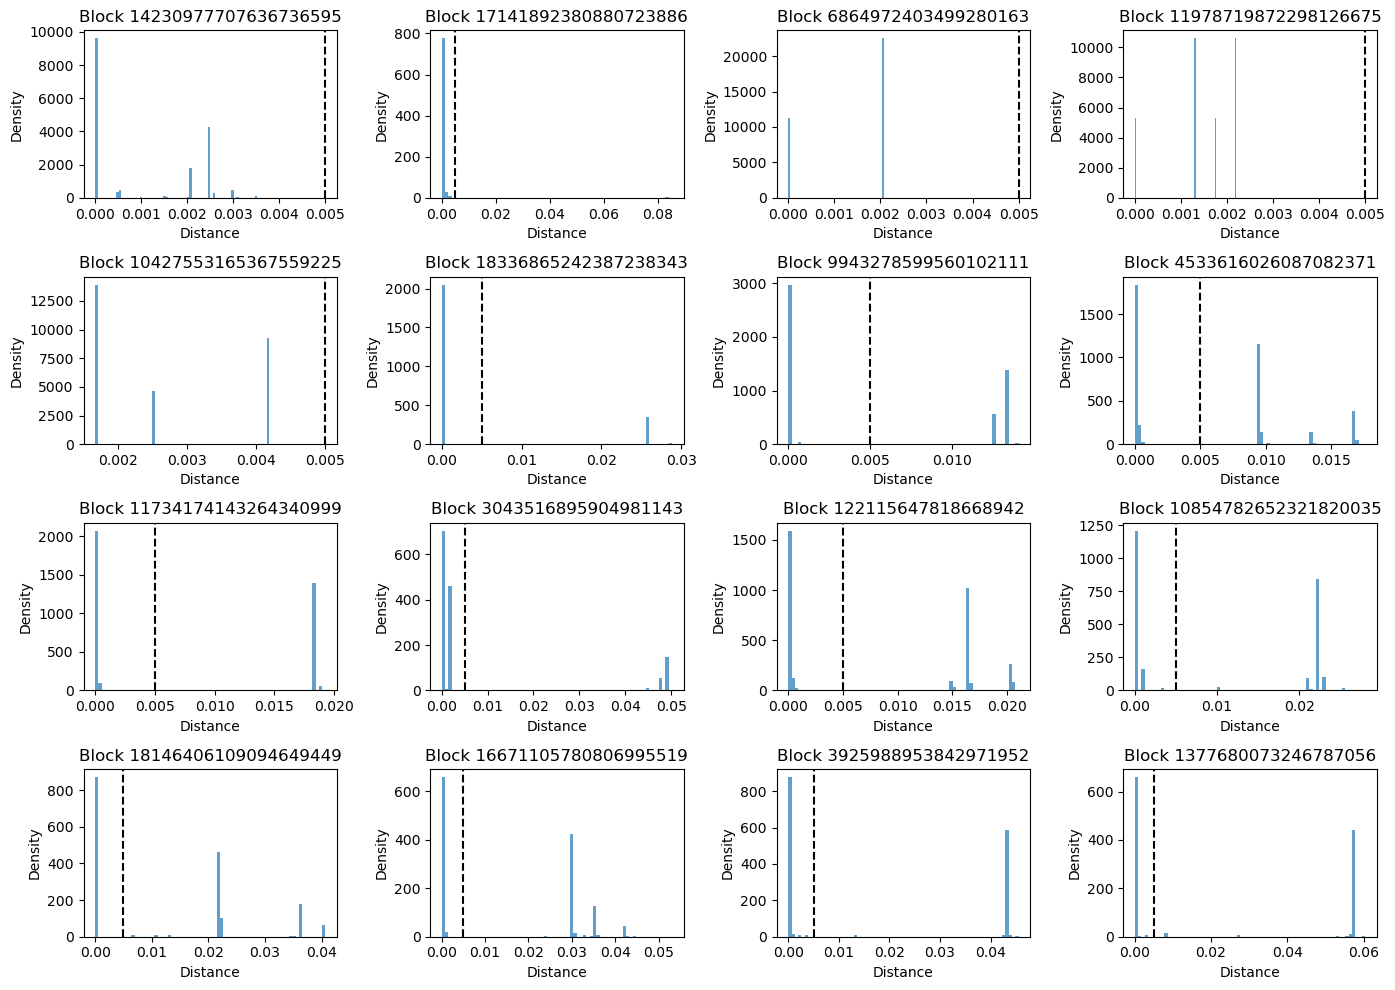

In [12]:
example_junction = "RYYAQMEJGY_r__ZTHKZYHPIX_f" # junction has 216 isolates
example_pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{example_junction}.json")

summary_df = pd.read_csv(f"../results/block_alignments/{example_junction}/{example_junction}_alignment_stats.csv")
display(summary_df.sort_values('avg_pairwise_dist')[summary_df.tree_built == True])

_, pair_dists = summarize_block_msas(example_junction, save_df=False, return_pairwise_dists=True)
block_ids = summary_df.sort_values('avg_pairwise_dist')[(summary_df.tree_built == True) & (summary_df.avg_pairwise_dist > 0.001)].block_id

plot_block_distance_distribution(
    pair_dists,
    block_ids,
    bins=70,
    cols=4,
    figsize=(14, 10),
    vline=0.005,                     # draw a vertical line at distance 0.05
    vline_kwargs={"color": "black", "linestyle": "--"}
)


In [13]:
block_id = 1377680073246787056 # block with highest diversity that is long enough and has enough sequences
#block_id = 3925988953842971952 # block with second highest diversity that is long enough and has enough sequences
#block_id = 8046715219054472333 # highest diversity block shared only by consensus_6, consensus_7 blocks
#block_id = 16671105780806995519	# first core block, also block with highest diversity that is present in all isolates --> gives very good clustering that fits desired consensus paths
#block_id = 18146406109094649449 # second core block


In [14]:
def visualize_block_clustering(pangraph, junction_name, consensus_paths, assignment_df, block_id, dist_threshold=0.005):

    tree_path = Path(f"../results/block_alignments/{junction_name}/block_{block_id}_aln.tree")

    cluster_map = cluster_tree_by_branch_length(tree_path, dist_threshold)
    cluster_map = simplify_cluster_keys(cluster_map)

    fig = plot_junction_pangraph_interactive(
        pangraph,
        show_consensus=True,
        consensus_paths=consensus_paths,
        assignments=assignment_df,
        order="tree",
        cluster_map=cluster_map,
        title = f"Junction Block Structure with block {block_id} Tree Clustering"
    )
    display(fig)

    return cluster_map

In [15]:
# block with highest diversity that is long enough and has enough sequences (blue block in the second half)
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 1377680073246787056, dist_threshold=0.005)
# clustering is consistent with consensus path clustering, two sequences are retrieved as a subcluster of consensus_1

# second highest diversity, light blue block in the first half
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 3925988953842971952, dist_threshold=0.005)
# clustering matches consensus path clustering for the consensus paths where block is present

# only present in consensus_5, red block in the middle
cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = 8046715219054472333, dist_threshold=0.005)
# all sequences cluster together as expected

In [16]:
for bid in block_ids:
    cluster_map = visualize_block_clustering(example_pangraph, example_junction, consensus_paths_plotting, assignment_df_plotting, block_id = bid, dist_threshold=0.005)

Results:
- most blocks fit the clustering of the core blocks
- some blocks suggest sub-clustering of some of the consensus baths (usually individual (1 or 2) isolates that differ), still consistent with core block clustering
- for some blocks suggest that several consensus paths should be the same cluster, e.g. 3043516895904981143 (also around 1000bp)
- 10854782652321820035 shows a little bit of intermixing between clusters, relativly short (around 1000bp, light blue)

### Check out other junctions

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/JVNRLCFAVD_f__PLTCZQCVRD_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0},

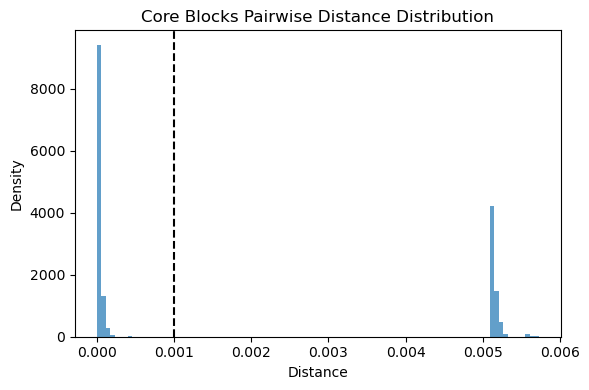

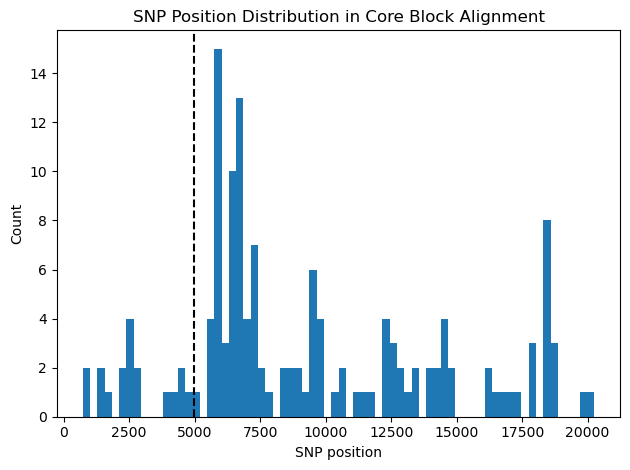

In [11]:
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("JVNRLCFAVD_f__PLTCZQCVRD_r", clustering_bl_thresh= 0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/ATPWUNKKID_f__KKPYPKGMXA_f
[{1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
169 / 169 isolates share the majority path
[{1}, {1}]
No ambiguous blocks.
52 / 52 isolates share the majority path


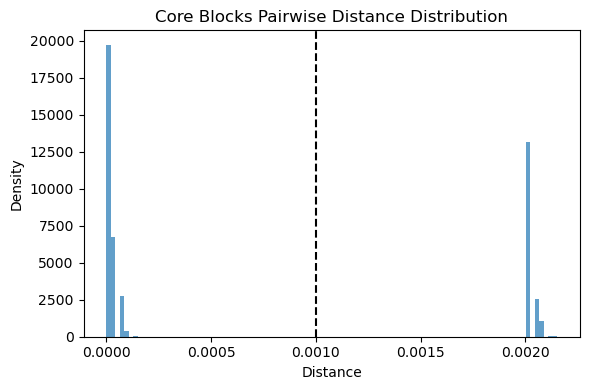

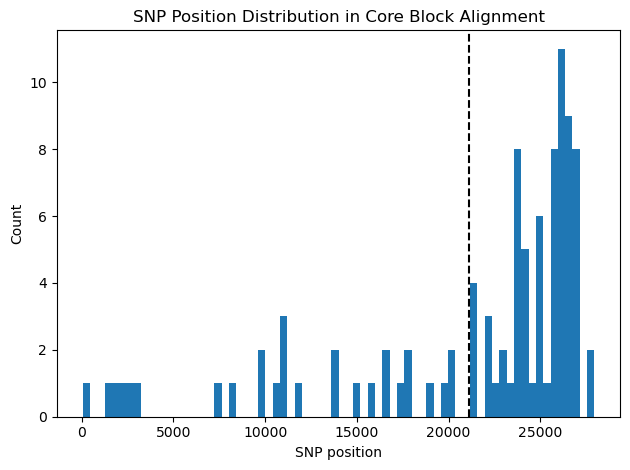

In [10]:
# branch length threshold 0.001 gives two consensus paths (its not directly representative of phage insertion and not insertion, paths that are in consensus 1 all have an insertion but not all of the ones in consensus 2 have one), 0.005 only one, 
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("ATPWUNKKID_f__KKPYPKGMXA_f", clustering_bl_thresh= 0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/EJPOGALASQ_f__KUIFCLFQSI_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0},

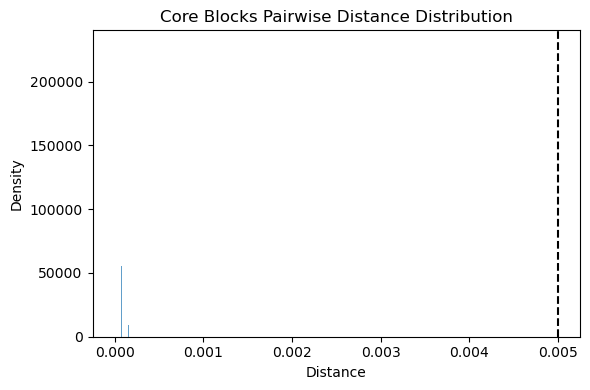

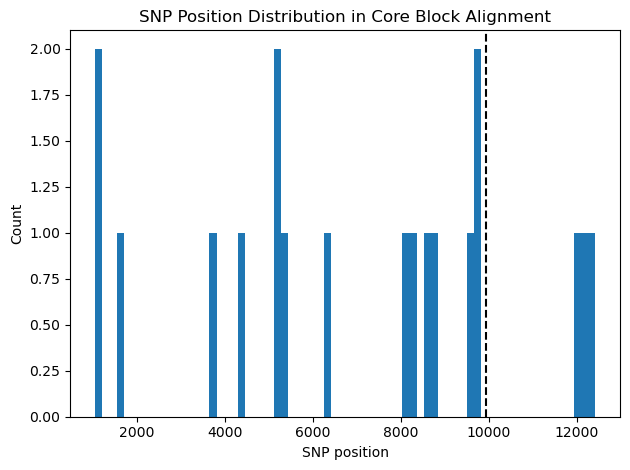

In [9]:
# should all be one cluster
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("EJPOGALASQ_f__KUIFCLFQSI_r", clustering_bl_thresh= 0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Skipping core: FASTA, alignment and tree already exist in ../results/consensus_analysis/CIRMBUYJFK_f__CWCCKOQCWZ_r
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}, {0}]
No ambiguous blocks.
160 / 170 isolates share the majority path
[{1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {1}, {0}, {0}]
No ambiguous blocks.
52 / 52 isolates share the majority path


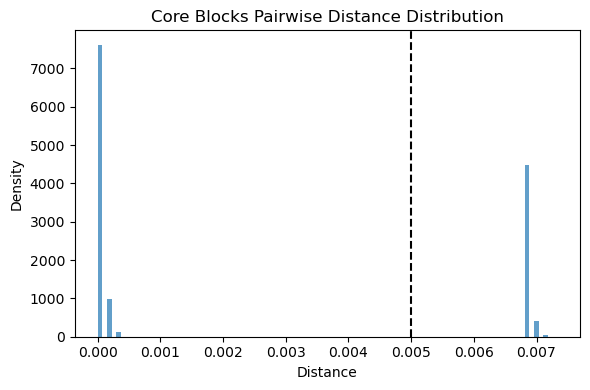

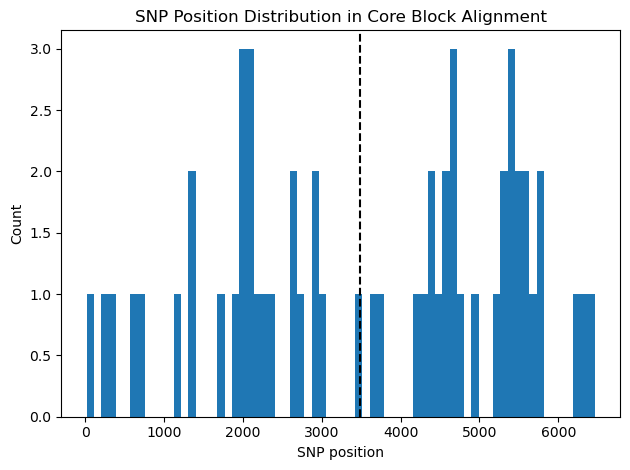

In [8]:
cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue = find_consensus_paths_core("CIRMBUYJFK_f__CWCCKOQCWZ_r", clustering_bl_thresh= 0.005, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk', plot_consensus=True, plot_pair_dist=True, plot_snp_dist=True, plot_ambiguities=True)

Compare the clusterings between different blocks. To do that look at all pairs of two isolates and compare whether they are in the same cluster or in different clusters. Then calculate a score how many of the isolates that are in the same cluster are also in the same cluster on a different block and how many aren't. Also calculate a score how many of the isolates that are in different clusters are also in different clusters on a different block. For now just use isolate names and ignore duplicate blocks.